# 📶 Investigation of CSI Error Impact on Spatial Precoding Algorithms

In the previous homework, we assumed perfect knowledge of the channel state information (CSI) at both the transmitter and receiver. This ideal assumption allowed us to construct optimal precoders and equalizers without accounting for estimation errors. In practical wireless systems, however, the channel must be estimated from measurements, and the accuracy of this estimation directly affects system performance.

Channel estimation is typically performed using specially designed reference signals that are known to both the transmitter and the receiver. These signals are referred to as **pilot signals**. In this homework, we focus on channel estimation using **Sounding Reference Signals (SRS)**, which were introduced in the lectures.

In the considered scenario, SRS signals are transmitted by the user equipment (UE) during the **uplink**, and received at the base station (BS). The base station uses the received SRS signals to estimate the uplink channel. Under the assumption of channel reciprocity, which holds in Time Division Duplex (TDD) systems, the estimated uplink channel can also be used as the downlink channel estimate. The base station then constructs a precoder based on this estimated CSI and uses it for **downlink data transmission** to the UE.

Thus, the overall transmission procedure consists of two stages:

- **Uplink:** transmission of SRS pilot signals for channel estimation,
- **Downlink:** transmission of data using a precoder constructed from the estimated CSI.

---

#### Practical Limitations of Channel Estimation

In real communication systems, pilot and data signals cannot occupy the same time–frequency resources simultaneously. For example, in TDD systems, specific OFDM symbols are allocated for pilot transmission, while the estimated CSI is used for data transmission during subsequent symbols.

As a result, practical CSI estimation is affected by several sources of error, including:

- thermal noise at the receiver,
- interference from other users transmitting in the same time–frequency resources,
- channel aging caused by temporal channel variations.

In this homework, we focus on analyzing the impact of **noise and inter-user interference** on channel estimation accuracy, precoder construction, and overall system performance. Channel aging effects are not considered in this assignment.

---

#### 🎯 Learning Objectives

By completing this assignment, you will:

1. Analyze and verify the correlation and orthogonality properties of Zadoff–Chu sequences.
2. Investigate signal properties in the delay domain.
3. Apply cyclically shifted Zadoff–Chu sequences for channel estimation using shared frequency resources.
4. Develop signal filtering strategies to improve channel estimation under noise and interference.
5. Evaluate the impact of CSI estimation errors on precoding performance and data transmission reliability.

> ⚠️ This homework builds directly on the simulator developed in the previous assignment. Ensure that your previous implementation is fully functional before proceeding.

In [1]:
import os
import scipy
import numpy as np
import matplotlib.pyplot as plt
from ModulationPy import PSKModem, QAMModem
from tqdm.notebook import tqdm, trange
from numpy import sqrt
plt.rcParams.update({'font.size': 15})

USE_GOOGLE_DRIVE = False
FOLDER_PATH = r'C:\Users\Lenovo\Desktop\MIMO\Files\\' 

# Which channel file you'd like to load
CHAN_NAME = 'link_chan_{}.mat'.format('2')                                  #  <<< Set your value here

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/gdrive')
    CHAN_NAME = 'link_chan_{}.mat'.format('2')

os.chdir(FOLDER_PATH)
print("Loading file:", FOLDER_PATH + CHAN_NAME)


Loading file: C:\Users\Lenovo\Desktop\MIMO\Files\\link_chan_2.mat


###  📕Channel structure
Let us load one of the `.mat` channel file and examine its shape. 

The ground true MIMO channel is represented as a complex-valued, high-dimentional tensor:
$$\mathcal{H} \in \mathbb{C}^{M \times N \times K \times T},$$
where:
- $M - $Number of antennas at the user equipment (UE) side (4),
- $N - $Number of antennas at the base station (BS) side (64),
- $K - $Number of OFDM subcarriers used for data transmission (600),
- $T - $Number of time instants at which the channel was measured (100).

For numerical stability we will use same channel normalisation, described in previous homework:

In [2]:
def normalize(H):
    '''
    Normalizes the channel along UE antennas and subcarriers to have unit power on each receive antenna.
    Inputs: 
        - H: (np.ndarray) the channel array with shape (100, 600, 4, 64)
    Outputs:
        -H_normed (np.ndarray) the channel array with shape (100, 600, 4, 64)
    '''
    N_ue = H.shape[-2]
    # Calculate norms along 0,2 axis (N_ue, N_f)
    norma = np.linalg.norm(H, ord = 'fro', axis = (-2,-3), keepdims = True)

    # return normalized channel
    H_normed = H / norma * sqrt(N_ue)
    return H_normed

In [3]:
# Uplink channel
H_UL = normalize(scipy.io.loadmat(CHAN_NAME)['Link_Channel'].transpose(3,2,1,0))
T,K,N,M = H_UL.shape

print('Uplink channel shape: ', H_UL.shape)

# Downlink. Due to reciprocity
H_DL = H_UL.conj().swapaxes(-1,-2)
print('Downlink channel shape: ', H_DL.shape)

Uplink channel shape:  (100, 600, 64, 4)
Downlink channel shape:  (100, 600, 4, 64)


In [4]:
# -------------------------------------------------
# Load second channel 
# -------------------------------------------------
CHAN_NAME_2 = 'link_chan_PATH.mat'

H_UL_2 = normalize(
    scipy.io.loadmat(CHAN_NAME_2)['Link_Channel']
    .transpose(3,2,1,0)
)

T2, K2, N2, M2 = H_UL_2.shape

H_DL_2 = H_UL_2.conj().swapaxes(-1,-2)

print('Second channel uplink shape:', H_UL_2.shape)
print('Second channel downlink shape:', H_DL_2.shape)

Second channel uplink shape: (100, 600, 64, 4)
Second channel downlink shape: (100, 600, 4, 64)


## Channel Impulse Response and Power Delay Profile

The properties of the MIMO channel $\mathcal{H}$ are characterized not only by its spatial structure (studied in the previous homework), but also by its temporal structure, which describes how signal energy is distributed over propagation delays.

For a fixed transmit–receive antenna pair $(m,n)$ and a fixed time instant $t$, the frequency-domain channel can be represented as a vector $\mathbf{h} \in \mathbb{C}^{K},$
where $K$ is the number of subcarriers.

The corresponding **channel impulse response (CIR)** in the delay domain can be obtained using the inverse discrete Fourier transform (IDFT):

$$
\mathbf{z}(\tau)
=
\sum_{k=0}^{K-1}
\mathbf{h}(k)
\exp\left(j\frac{2\pi}{K}k\tau\right),
\qquad
\tau = 0,1,\ldots,K-1.
$$

The vector $\mathbf{z}(\tau)$ represents the complex-valued channel response as a function of discrete propagation delay $\tau$. Each peak in $|\mathbf{z}(\tau)|$ corresponds to a multipath propagation component with a specific delay.

---

### Power Delay Profile

In practice, we are often interested in the **power delay profile (PDP)**, defined as

$$
\mathrm{PDP}(\tau)
=
|\mathbf{z}(\tau)|^2.
$$

The PDP describes how the received signal power is distributed across different propagation delays.

To obtain a more robust estimate, the PDP is typically averaged across multiple antenna pairs:

$$
\overline{\mathrm{PDP}}(\tau)
=
\frac{1}{MN}
\sum_{m=1}^{M}
\sum_{n=1}^{N}
|\mathbf{z}_{m,n}(\tau)|^2.
$$

This averaging reduces small-scale fading effects and reveals the dominant multipath structure of the channel.

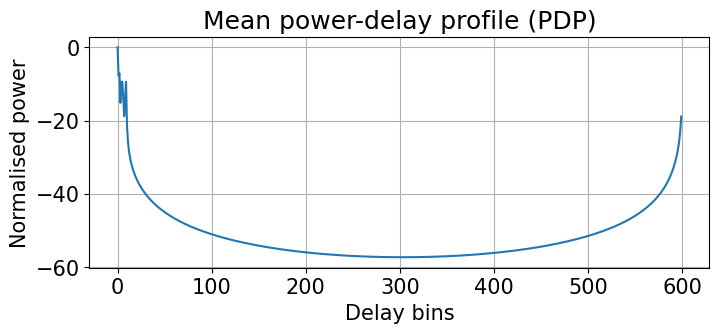

In [5]:
from numpy.fft import fft, ifft, fftshift 
def get_pdp(Ht, normalize=False, avg_dims=(-1, -2)):
    '''
    Calculates averaged per antennas power-delay profile (PDP)
    :param Ht: (np.ndarray) Channel array with shape (K, M, N) or (K, N, M)
    :param normalize: (bool) Whether to use infinity norm for resulting pdp
    :param avg_dims: (tuple) the dimensions for averaging pdp
    :return: (np.ndarray) averaged along avg_dims power-delay profile
    '''
    assert len(Ht.shape) == 3, 'Expected 3 dimensional array'

    # CIR (delay-domain channel) from frequency-domain H: IDFT over subcarriers axis (K)
    cir = ifft(Ht, axis=0, norm="ortho")          # shape (K, M, N) (or (K, N, M))

    # PDP: average power over antenna dimensions
    pdp_mean = np.mean(np.abs(cir)**2, axis=avg_dims)   # shape (K,)

    if normalize:
        # infinity norm (for visualisation)
        pdp_mean = pdp_mean / np.max(pdp_mean, axis=0, keepdims=True)

    return pdp_mean

pdp = get_pdp(H_UL[0], normalize = True, avg_dims = (-2,-1))
# axis (-2,-1) means we average over the last two dimensions of the array, which correspond to the receive antennas and the transmit antenna ports.
plt.figure(figsize = (8,3))
plt.plot(10*np.log10(pdp))  # log scale is commonly used to visualize side lobes
plt.grid()
plt.title('Mean power-delay profile (PDP)')
plt.ylabel('Normalised power')
plt.xlabel('Delay bins')
plt.show()

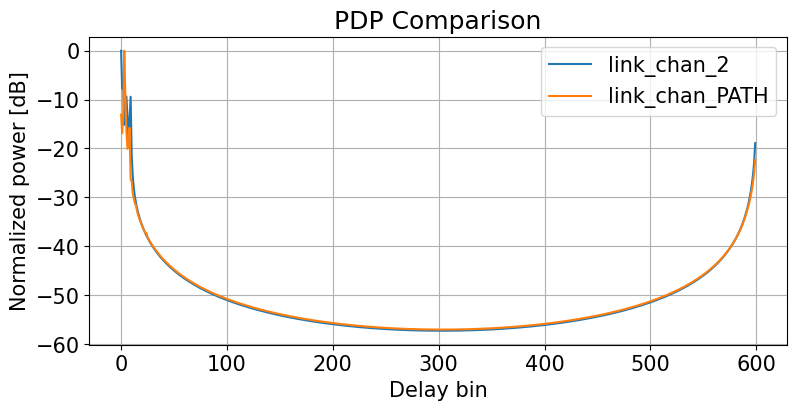

In [6]:
t0 = 0

pdp_main  = get_pdp(H_UL[t0], normalize=True, avg_dims=(-2,-1))
pdp_path  = get_pdp(H_UL_2[t0], normalize=True, avg_dims=(-2,-1))

plt.figure(figsize=(9,4))
plt.plot(10*np.log10(pdp_main + 1e-12), label='link_chan_2')
plt.plot(10*np.log10(pdp_path + 1e-12), label='link_chan_PATH')
plt.grid()
plt.legend()
plt.title('PDP Comparison')
plt.xlabel('Delay bin')
plt.ylabel('Normalized power [dB]')
plt.show()

## 📌 RMS Delay Spread

Let the power delay profile be

$$
\mathrm{PDP}(\tau), \quad \tau = 0,1,\dots,K-1.
$$

### Normalized PDP

$$
p(\tau) =
\frac{\mathrm{PDP}(\tau)}
{\sum_{\tau=0}^{K-1} \mathrm{PDP}(\tau)}.
$$

### First Moment (Mean Delay)

$$
\mu =
\sum_{\tau=0}^{K-1}
\tau \, p(\tau).
$$

### Second Moment

$$
\mu_2 =
\sum_{\tau=0}^{K-1}
\tau^2 \, p(\tau).
$$

### RMS Delay Spread

The variance of the delay distribution is

$$
\sigma_\tau^2 =
\mu_2 - \mu^2.
$$

Therefore, the RMS delay spread is

$$
\sigma_\tau =
\sqrt{
\sum_{\tau=0}^{K-1} \tau^2 p(\tau)
-
\left(
\sum_{\tau=0}^{K-1} \tau p(\tau)
\right)^2
}.
$$

The RMS delay spread quantifies how widely the multipath energy is distributed around the mean delay.

In [7]:
def rms_delay_spread_bins(pdp):
    p = pdp / (np.sum(pdp) + 1e-15) #normalize so total power = 1 (avoid division by zero with small epsilon)
    tau = np.arange(len(p))  # create the delay index --tau = [0, 1, 2, ..., K-1].
    mu = np.sum(tau * p) #mean delay, where  is the average power located
# if most energy is early, mu will be small, if most energy is late, mu will be large

    mu2 = np.sum((tau**2) * p) # compute the seond moment of the delay distribution
    return float(np.sqrt(max(mu2 - mu**2, 0.0)))



## 📌 Energy-Based Delay Window Selection

Let the power delay profile (PDP) be

$$
\mathrm{PDP}(\tau), \quad \tau = 0,1,\dots,K-1.
$$

### 1 Normalized PDP

We first normalize the PDP so that total energy equals 1:

$$
p(\tau) =
\frac{\mathrm{PDP}(\tau)}
{\sum_{\tau=0}^{K-1} \mathrm{PDP}(\tau)}.
$$

Then,

$$
\sum_{\tau=0}^{K-1} p(\tau) = 1.
$$

### 2️ Definition of Energy Window

We want to find the smallest contiguous delay window
that contains at least a fraction $\text{frac}$ of the total energy:

$$
\sum_{\tau \in \mathcal{W}} p(\tau) \ge \text{frac}.
$$

The window length is defined as

$$
L = |\mathcal{W}|.
$$

### 3️ Circular Window (Wrap-Around)

Because the delay domain is circular (due to IDFT),
windows are allowed to wrap around:

$$
\mathcal{W} = \{s, s+1, \dots, s+L-1\} \mod K.
$$


For example:

- If $\text{frac} = 0.90$, then $L_{90}$ is obtained.
- If $\text{frac} = 0.99$, then $L_{99}$ is obtained.

In [8]:
def energy_window_len(pdp, frac=0.99):
    K = len(pdp)
    p = pdp / (np.sum(pdp) + 1e-15)

    p2 = np.concatenate([p, p]) # make a length 2K array by concatenating p with itself, to handle circular windows that wrap around the end of the array
    c = np.cumsum(p2)  #cumulative sum of power, where c[i] is the total power in the first i delay bins of p2
    c = np.concatenate([[0.0], c]) 
    best_len, best_start = K+1, 0 #best length is the smallest window length that contains at least frac of the total energy, best start is the starting index of that window
    for s in range(K):
        target = c[s] + frac
        e = np.searchsorted(c, target, side="left") # find the smallest index e such that c[e] >= target, which means the window from s to e contains at least frac of the total energy
        L = e - s  #window length 
        if L < best_len:
            best_len, best_start = L, s
    return int(best_len), int(best_start)
#The algorithm searches over all possible starting positions and selects the window that captures the required fraction of energy 
# with the minimum length, thereby ensuring maximum noise suppression while preserving the dominant channel components.

In [9]:

for name, pdp in [("link_chan_2", pdp_main), ("link_chan_PATH", pdp_path)]:
    rms = rms_delay_spread_bins(pdp)
    L90,_ = energy_window_len(pdp, 0.90)
    L99,_ = energy_window_len(pdp, 0.99)
    print(f"{name}: RMS={rms:.2f} bins, L90={L90}, L99={L99}")

link_chan_2: RMS=77.70 bins, L90=9, L99=17
link_chan_PATH: RMS=74.17 bins, L90=5, L99=22


### 🔴 Questions
1. Discuss what are the properties of observed PDP? How many samples and in which positions you need to describe this signal uniquely? What is the difference for channel `link_chan_PATH.mat`?
2. Why do we have some non-zero samples closer to the end of PDP? 

## 📕 Zadoff–Chu (ZC) Sequences

Zadoff–Chu sequences are complex-valued sequences with constant amplitude and ideal correlation properties, which makes them highly suitable for channel estimation.

The general expression for a Zadoff–Chu sequence of length $K$ is given by

$$
s(k)
=
\exp\left(
-j\frac{\pi r k (k + k_c + 2q)}{K}
\right),
$$

where:

- $k = \{0,1,\ldots,K-1\}$ is the sequence index,
- $K$ is the sequence length,
- $k_c = K \bmod 2$ accounts for even and odd sequence lengths,
- $r$ is the root index of the sequence, satisfying $\gcd(r,K) = 1$,
- $q \in \mathbb{Z}$ is the cyclic shift index.

Zadoff-Chu sequence is periodic: $s(k+K) = s(k)$. Some other important properties will be analysed after implementation.

---

### Application to Channel Estimation

These properties enable simultaneous channel estimation for multiple antennas and users.

- Different users can be assigned different roots $r$,
- Different transmit antennas can be assigned different cyclic shifts $\tau$.

For a user with $M$ transmit antennas, the pilot matrix

$$
\mathbf{S} \in \mathbb{C}^{M \times K}
$$

can be constructed as

$$
S(m,k)
=
\exp\left(
-j\frac{\pi r k (k + k_c + 2m\Delta_m)}{K}
\right),
$$

where:

- $m = 0,1,\ldots,M-1$ is the antenna index,
- $\Delta_m$ is the cyclic shift spacing between antennas (in delay bins).

This structure allows the receiver to separate and estimate the channel corresponding to each antenna independently using correlation-based methods.

In [10]:
import numpy as np

def toy_srs_zc(K, M, shift_step, root):
    '''
    Generates toy example of srs signal using Zadoff-Chu sequence
    :param K: (int) Sequence length (number of subcarriers K)
    :param M: (int) Number of antenna ports within one UE 
    :param shift_step: (int) Cyclic shift for different antenna ports in delay bins
    :param root: (int) Root of the Zadoff-Chu sequence.
     
    :return: matrix S (np.ndarray) with shape of (K, M)
    '''
    n = np.arange(K)

    # Correct ZC depending on parity of K
    if K % 2 == 0:
        zc = np.exp(-1j * np.pi * root * (n**2) / K)          # even K-- For even K, the ZC sequence is defined as exp(-j * pi * root * n^2 / K)
    else:
        zc = np.exp(-1j * np.pi * root * n * (n + 1) / K)     # odd K-- For odd K, the ZC sequence is defined as exp(-j * pi * root * n * (n + 1) / K)

    S = np.zeros((K, M), dtype=complex)

    for m in range(M):
        shift = m * shift_step   #Compute cyclic shift in samples: shift = m × shift_step
#        (shift_step = 50 for example then shifts of 0, 50, 100, 150 samples)
        phase_ramp = np.exp(+1j * 2 * np.pi * shift * n / K)
        S[:, m] = zc * phase_ramp   # A cyclic shift by L samples in time domain = multiplication by phase ramp in frequency domain: 
        #S_m = ZC * exp(+j * 2 * pi * L * n / K)

    return S
# It must satisfy gcd(r, K) = 1 (greatest common divisor = 1), so that the sequence has perfect autocorrelation properties.
# parameter controlling how “fast” the phase rotates, 11 is prime and does not divide 600.
S = toy_srs_zc(K=K, M=M, shift_step=50, root=11)
print('Pilots shape: ', S.shape)

Pilots shape:  (600, 4)


### Key Properties of Zadoff–Chu Sequences

Zadoff–Chu sequences possess several important properties that make them ideal for pilot-based channel estimation:

1. **Perfect cyclic autocorrelation**

   The autocorrelation of a Zadoff–Chu sequence with its cyclically shifted version is zero for all non-zero shifts:

   $$
   R(\tau)
   =
   \sum_{k=0}^{K-1}
   s(k)
   s^*(k-\tau)
   =
   \begin{cases}
   K, & \tau = 0 \\
   0, & \tau \ne 0
   \end{cases}
   $$

   This property enables accurate estimation of propagation delays.


In [11]:
#We generated frequency-domain pilot sequences.

#Then we computed their circular cross-correlation.

#The result is a delay-indexed function that shows how the sequences are shifted versions of each other.

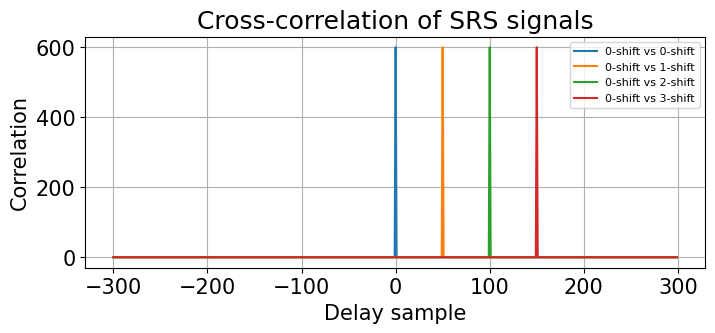

In [12]:
    def get_dft_axis(K:int):
        '''Reorders axis according to DFT, having 0 DFT bin in the middle of input vector'''
        
        # if Number of elements is even
        if K % 2 == 0:
            k_axis =  np.arange(start = - K//2, stop = K//2 , step = 1)
        
        # if Number of elements is odd
        else:
            k_axis = np.arange(start = -(K-1)//2, stop = (K-1)//2 + 1, step = 1)
        return k_axis

    def correlate_freq_domain(x1, x2):
        # circular correlation using spectral theorem
        corr = np.fft.ifft(np.fft.fft(x1) * np.conj(np.fft.fft(x2)))   # circular correlation can be computed as IFFT of the product of FFTs (with one conjugated)
    #circular cross-correlation between two sequences
        abs_corr = np.abs(corr)  #magnitude of correlation (we are interested in correlation peaks, not their phase)
        return np.fft.fftshift(abs_corr)  #center the correlation around zero delay (0 DFT bin in the middle of input vector)

    plt.figure(figsize = (8,3))
    for m in range(S.shape[1]):
        corr = correlate_freq_domain(S[:,0], S[:,m])
        plt.plot(get_dft_axis(K), corr, label = '0-shift vs {0}-shift'.format(m) )
    plt.ylabel('Correlation')
    plt.xlabel('Delay sample')
    plt.title('Cross-correlation of SRS signals')
    plt.grid()
    plt.legend(fontsize = 8)
    plt.show()

    # Ports are separated in delay domain

2. **Time-Domain Cross-Correlation Property**:

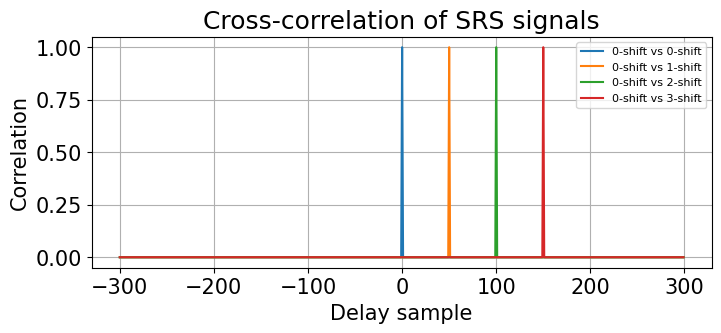

In [13]:
def correlate_time_domain(x1, x2):
    corr = np.fft.ifft(x1 * np.conj(x2))
    abs_corr = np.abs(corr)
    return np.fft.fftshift(abs_corr)

plt.figure(figsize = (8,3))
for m in range(S.shape[1]):
    corr = correlate_time_domain(S[:,0], S[:,m])
    plt.plot(get_dft_axis(K), corr, label = '0-shift vs {0}-shift'.format(m) )
plt.ylabel('Correlation')
plt.xlabel('Delay sample')
plt.title('Cross-correlation of SRS signals')
plt.grid()
plt.legend(fontsize = 8)
plt.show()

3. **Constant cross-correlation magnitude**

   The cross-correlation between two Zadoff–Chu sequences with different roots has constant magnitude:

   $$
   |R_{12}(\tau)| = \frac{1}{\sqrt{K}},
   $$

   provided that the difference between the roots is relatively prime to $K$.

   This allows separation of signals transmitted by different users.


In [14]:
S1 = toy_srs_zc(K=599, M=4, shift_step=50, root=13)
S2 = toy_srs_zc(K=599, M=4, shift_step=50, root=11)

corr = correlate_time_domain(S1[:,0], S2[:,0])
expected_value = 1/np.sqrt(599)  #the magnitude of the cross-correlation between two different ZC sequences should be constant and equal to 1/sqrt(K) 
#for all shifts, where K is the sequence length (599 in this case).

print('Constant cross-correlation: ', np.all(np.isclose(corr, expected_value)))

Constant cross-correlation:  True


4. **Constant amplitude**

   $$
   |s(k)| = 1, \quad \forall k
   $$

   This property ensures efficient power amplification and avoids signal distortion.

In [15]:
print('Constant amplitude: ', np.all(np.isclose(np.abs(S), 1)))

Constant amplitude:  True


## 📡 Pilot Transmission and Channel Estimation

In the previous homework, we used the following uplink received signal model (time index $t$ is omitted for simplicity):

$$
\underset{N \times 1}{\mathbf{y}(k)}
=
\underset{N \times M}{\mathbf{H}(k)}
\;
\underset{M \times 1}{\mathbf{s}(k)}
+
\underset{N \times 1}{\mathbf{n}(k)},
$$

where:

- $\mathbf{y}(k) \in \mathbb{C}^{N}$ is the received signal at the base station,
- $\mathbf{H}(k) \in \mathbb{C}^{N \times M}$ is the channel matrix,
- $\mathbf{s}(k) \in \mathbb{C}^{M}$ is the transmitted pilot vector,
- $\mathbf{n}(k) \in \mathbb{C}^{N}$ is additive white Gaussian noise.


In [16]:
def get_noise(signal, SNR_dB):
    '''Returns complex AWGN tensor for a signal with the same shape
       satisfying SNR ratio
        Inputs:
            - signal: (np.ndarray) some signal array with shape of (100, 600, 4, 64)
            - SNR: (int) SNR value in decibels, which adjusts noise power.
                    if SNR is None, return 0 (no noise at all)
       '''
    if SNR_dB is None:
        return 0
    
    # complex-valued AWGN with 0 mean and unit variance with same size as @signal
    noise = np.sqrt(1/2) * (np.random.randn(*signal.shape) + 1j*np.random.randn(*signal.shape))
    
    # Calculate mean signal power
    P_signal = np.mean(np.abs(signal)**2, axis = (-1,-2,-3), keepdims = True)

    # Normalize Noise to satisfy SNR
    noise_normed = noise * sqrt(10**(-SNR_dB/10) * P_signal)
    return noise_normed

def receiver_signal(H, X, SNR_dB):
    noise = get_noise(np.mean(H, -1, keepdims=True) * sqrt(64), SNR_dB)
    return H @ X + noise 

# === NEW: shift_step is now a variable so we can test the professor's suggestion ===
shift_step = 50          #  keep 50 for ALL your main results (BER curves, etc.)
# shift_step = 25        

S = toy_srs_zc(K=K, M=M, shift_step=shift_step, root=11)
print('Pilots shape: ', S.shape, f'  (shift_step = {shift_step})')

# fix time moment
Y = receiver_signal(H_UL[0], S[..., None], SNR_dB = None) # S[..., None] adds an extra dimension to S, making its shape (K, M, 1) 
#so that it can be multiplied with H which has shape (K, M, N)
# that mean for each subcarrier, M antenna ports, 1 OFDM symbol

print('RX shape: ', Y.shape)

Pilots shape:  (600, 4)   (shift_step = 50)
RX shape:  (600, 64, 1)


## Alternative Matrix Representation

To analyze pilot-based channel estimation more conveniently, it is useful to express the model across all subcarriers simultaneously.

Let us collect the received signals across all $K$ subcarriers into a matrix:

$$
\underset{N \times K}{\mathbf{Y}}
=
\sum_{m=0}^{M-1}
\underset{N \times K}{\mathbf{H}(m)}
\;
\underset{K \times K}{\mathbf{S}(m)}
+
\underset{N \times K}{\mathbf{N}},
$$

where:

- $\mathbf{Y} \in \mathbb{C}^{N \times K}$ is the received signal matrix,
- $\mathbf{H}(m) \in \mathbb{C}^{N \times K}$ is the channel frequency response corresponding to transmit antenna $m$,
- $\mathbf{S}(m) \in \mathbb{C}^{K \times K}$ is a diagonal matrix containing pilot symbols transmitted by antenna $m$:

$$
\mathbf{S}(m) = \mathrm{diag}\left(s(m,0), s(m,1), \ldots, s(m,K-1)\right),
$$

- $\mathbf{N} \in \mathbb{C}^{N \times K}$ is the noise matrix.

This representation is mathematically equivalent to the per-subcarrier model but provides a more convenient framework for channel estimation analysis.

The receiver knows the transmitted pilot matrices $\mathbf{S}(m)$ and observes $\mathbf{Y}$. The goal is to estimate the channel matrices $\mathbf{H}(m)$.


## Channel Estimation Algorithm

Based on the orthogonality properties of Zadoff–Chu sequences, channel estimation can be performed using the following steps.

### Step 1: Least Squares (LS) Estimation

For each transmit antenna $m$, the least squares estimate of the channel is obtained by correlating the received signal with the conjugate pilot sequence:

$$
\mathbf{H}_{\mathrm{LS}}(m)
=
\mathbf{Y}
\;
\mathbf{S}^+(m) = \mathbf{Y}\mathbf{S}(m)^H(\mathbf{S}(m)\mathbf{S}(m)^H)^{-1} = \mathbf{Y}\mathbf{S}(m)^H,
$$
where 
- $()^+$ denotes Moore-Penrose inversion 
- $\mathbf{H}_{\mathrm{LS}}(m) \in \mathbb{C}^{N\times K}$ - LS channel estimation

Last equation is held due to Zadoff-Chu property: $\mathbf{S}(m)\mathbf{S}(m)^H = \mathbf{I}$ 

Stacking all antenna estimates together yields the estimated channel tensor:

$$
\underset{M \times N \times K}{\mathcal{H}_{\mathrm{LS}}}
=
\left[
\mathbf{H}_{\mathrm{LS}}(0),
\mathbf{H}_{\mathrm{LS}}(1),
\ldots,
\mathbf{H}_{\mathrm{LS}}(M-1)
\right].
$$

This step separates the contributions of different transmit antennas using pilot orthogonality.

### Step 2: Transformation to Delay Domain
Next, we transform the channel estimate from the frequency domain to the delay domain using the inverse discrete Fourier transform (IDFT):

$$
\mathcal{Z}(m,n,\tau)
=
\frac{1}{\sqrt{K}}
\sum_{k=0}^{K-1}
\mathcal{H}_{\mathrm{LS}}(m,n,k)
\exp\left(
j \frac{2\pi}{K} k \tau
\right),
$$

where:

- $\tau = 0,1,\ldots,K-1$ is the delay index.

This step converts the channel into its impulse response representation, where different propagation paths appear as peaks at different delays.


In [17]:
# # Y: (K, N, 1)
# # S: (K, M)

# H_LS = Y * np.conj(S)[:, None, :]   # (K, N, M)

# print('H_est shape: ', H_LS.shape)

In [18]:
def estimate_H_LS_from_Y(Y, S):
    """
    Y: (K, N, 1)
    S: (K, M)
    returns H_LS: (K, N, M)
    """
    K, N, _ = Y.shape  # K is number of subcarriers, N is number of receive antennas,
    M = S.shape[1] #M is number of antenna ports (M=4 in our case)

    H_LS = np.zeros((K, N, M), dtype=complex)

    for m in range(M):
        # Correlate using the port-m sequence in freq domain:
        # Equivalent in delay-domain: multiply by conj(s) in freq then ifft
        tmp = np.fft.ifft(Y[:, :, 0] * np.conj(S[:, m])[:, None], axis=0, norm="ortho")  # (K,N)

        H_LS[:, :, m] = np.fft.fft(tmp, axis=0, norm="ortho")  # back to freq

    return H_LS

#Y = H S, Multiply by S* → removes pilot → gives H(k)

#IFFT → reveals multipath delays, FFT → return to frequency for OFDM processing

In [19]:
# 2) receive pilots (choose a time instant, and SNR)
t0 = 0
snr_db = None
Y_pilots = receiver_signal(H_UL[t0], S[..., None], SNR_dB=snr_db)  # (K,N,1)

# 3) LS estimate
H_LS = estimate_H_LS_from_Y(Y_pilots, S)             # (K,N,M)

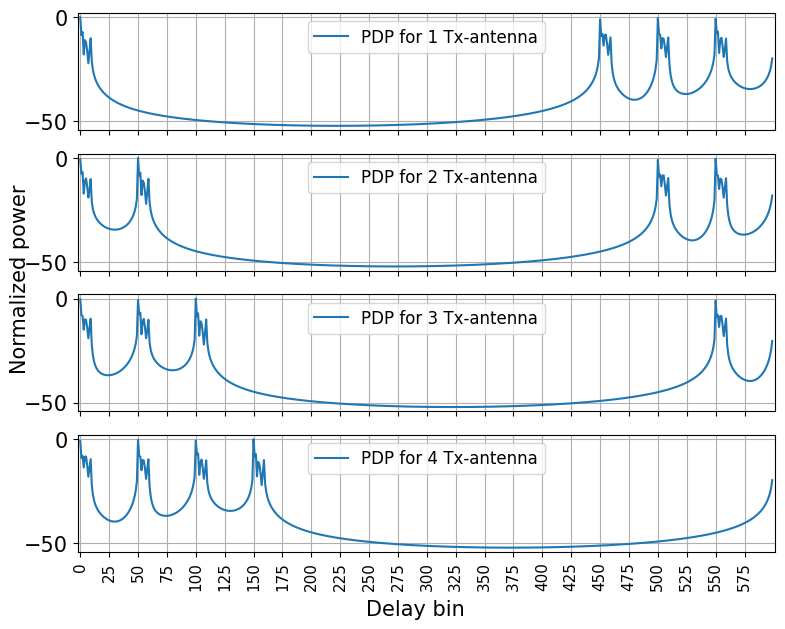

In [20]:
pdp_normed = get_pdp(H_LS, normalize = True, avg_dims = (-2)) # average over receive antennas, keep port dimension to see port separation in delay

fig, ax = plt.subplots(nrows=4, ncols=1, sharex=True, sharey=True, figsize=(9, 7))
for i,ax in enumerate(ax):
    ax.plot(10*np.log10(pdp_normed[:,i]), label = 'PDP for {} Tx-antenna'.format(i+1))
    ax.legend(fontsize = 12, loc ='upper center')
    ax.margins(0.004, 0.04)
    ax.set_xticks(np.arange(0, 600, 25))
    ax.tick_params(axis='x', labelsize=11, rotation=90)
    ax.grid()
    
fig.text(0.5, 0.02, 'Delay bin', ha='center')
fig.text(0.05, 0.5, 'Normalized power', va='center', rotation='vertical')
plt.show()

#All antennas have similar multipath shape but each appears in its own delay window.

### Step 3: Delay-Domain Filtering

Due to the cyclic shift properties of Zadoff–Chu sequences, the desired channel impulse response components appear within a specific delay region, while interference and cyclic replicas appear at other delay locations.

To suppress unwanted components, delay-domain filtering is applied using a diagonal masking matrix:

$$
\underset{K \times 1}{\hat{\mathbf{z}}(m,n)}
=
\underset{K \times K}{\mathbf{M}}
\;
\underset{K \times 1}{\mathbf{z}(m,n)},
$$

where:

- $\mathbf{M}$ is a diagonal binary matrix,
- desired delay components are preserved (mask value 1),
- undesired components are suppressed (mask value 0).

This operation improves estimation accuracy by removing interference and noise contributions outside the expected delay region.


In [21]:
def plot_pdp_per_antenna(H_LS):
    """
    H_LS: (K, N, M)
    K = delay bins
    N = RX antennas
    M = TX antennas
    """
    eps = 1e-12
    K, N, M = H_LS.shape

    # Convert to delay domain
    Z = ifft(H_LS, axis=0, norm="ortho")   # (K, N, M)

    plt.figure(figsize=(10, 6))

    for m in range(M):
        # PDP for antenna m
        pdp_m = np.mean(np.abs(Z[:, :, m])**2, axis=1)

        # Normalize
        pdp_m = pdp_m / (np.max(pdp_m) + eps)
        pdp_db = 10 * np.log10(pdp_m + eps)

        # Find peak location
        peak_idx = np.argmax(pdp_m)
        plt.plot(pdp_db, lw=2, label=f"Antenna {m+1} (peak @ {peak_idx})")
        plt.scatter(peak_idx, pdp_db[peak_idx], s=60)

    plt.title("PDP per antenna (separated)")
    plt.xlabel("Delay bin")
    plt.ylabel("Normalized Power [dB]")
    plt.grid(True, alpha=0.6)
    plt.legend()
    plt.ylim([-60, 5])
    plt.show()

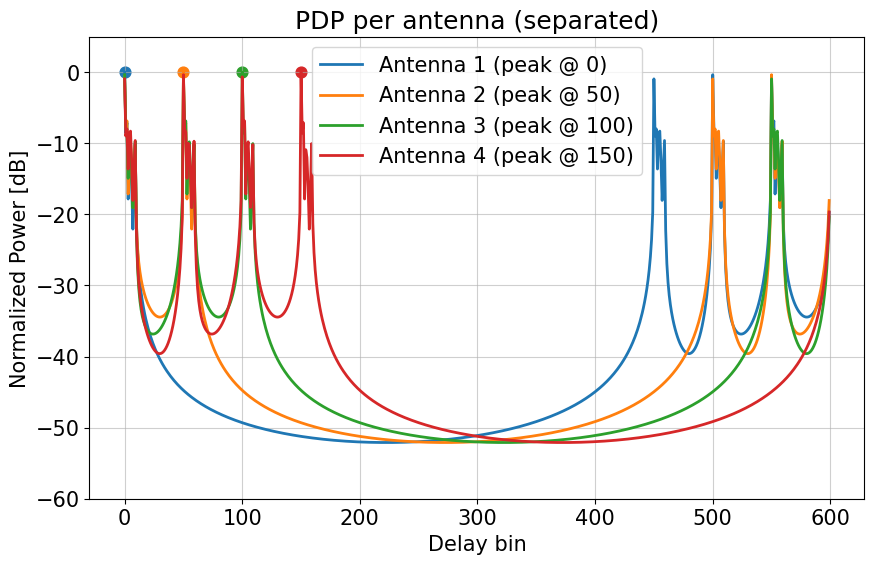

In [22]:
plot_pdp_per_antenna(H_LS)

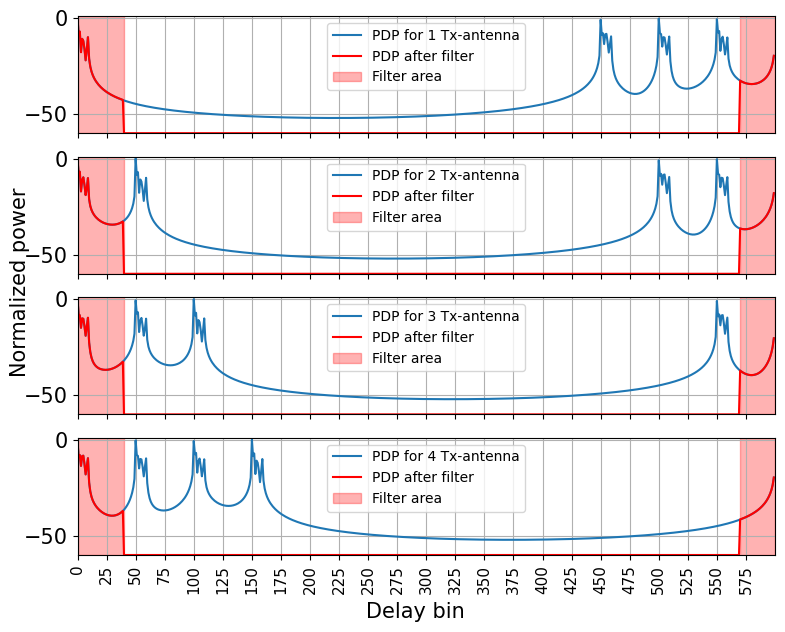

In [23]:
# This is just an illustration of the target achieved with window

w = np.zeros(600)
w[0:40] = 1
w[570:600] = 1

fig, ax_ar = plt.subplots(nrows=4, ncols=1, sharex=True, sharey=True, figsize=(9, 7))
for i, ax in enumerate(ax_ar):
    ax.plot(10*np.log10(pdp_normed[:,i]), label = 'PDP for {} Tx-antenna'.format(i+1))
    ax.plot(10*np.log10(pdp_normed[:,i]*w+1e-6),'-',color = 'r', label = 'PDP after filter'.format(i+1))
    ax.fill_betweenx([-60, 1],0, 40, alpha = 0.3, color = 'r', label = 'Filter area')
    ax.fill_betweenx([-60, 1],570, 600, alpha = 0.3, color = 'r')
    ax.legend(fontsize = 10, loc ='upper center')
    ax.margins(0.00, 0.0)
    ax.set_xticks(np.arange(0, 600, 25))
    ax.tick_params(axis='x', labelsize=11, rotation=90)
    ax.grid()
    
    
fig.text(0.5, 0.02, 'Delay bin', ha='center')
fig.text(0.05, 0.5, 'Normalized power', va='center', rotation='vertical')
plt.show()

In [24]:
print(H_UL.shape)
print(H_UL[0].shape)

(100, 600, 64, 4)
(600, 64, 4)


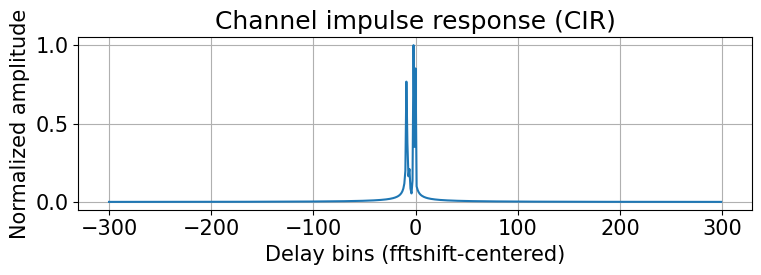

In [25]:
# CIR plotting for a fixed antenna pair (1D frequency response of length K)
def plot_CIR(x, K):
    x = np.asarray(x).squeeze()
    assert x.ndim == 1, f'Only vectors are allowed, got shape {x.shape}'

    cir = fftshift(np.abs(ifft(x, norm="ortho")))
    cir_normalized = cir / (np.max(cir) + 1e-12)

    plt.figure(figsize=(8,3))
    plt.plot(get_dft_axis(K), cir_normalized)
    plt.grid(True)
    plt.title('Channel impulse response (CIR)')
    plt.ylabel('Normalized amplitude')
    plt.xlabel('Delay bins (fftshift-centered)')
    plt.tight_layout()
    plt.show()

t0 = 0
ue_port = 0   
bs_ant  = 0   

x = H_DL[t0, :, ue_port, bs_ant]   # (K,)
plot_CIR(x, K)

## coder

In [26]:
def make_window(K, length, position):
    #K is the total length of the window(my case 600), length is the length of the non-zero part, position is the starting index of the non-zero part
    w = np.zeros(K, dtype=float)
    w[(position + np.arange(length)) % K] = 1.0
    # np.arange(length) generates 0, 1, 2, ..., length-1
    #position + ... shifts that block to start at position
    # %k wraps around the window if it exceeds K
    #then set those selected bins to 1
    return w

In [27]:
def apply_delay_window_to_H_LS(H_LS, w): #H_LS is the estimated channel in frequency domain, w is the delay-domain window
    Z = ifft(H_LS, axis=0, norm="ortho")
    Z_hat = Z * w[:, None, None]
    #Z has shape (K, N, M), w has shape (K,), w[:, None, None] broadcasts w to shape (K, 1, 1) so that it can be multiplied element-wise with Z across the K dimension
    return fft(Z_hat, axis=0, norm="ortho")

In [28]:
#automatically select window parameters based on CIR power, SNR, and pilot shift spacing

def adaptive_window_from_cir_power(cir_pwr_norm, snr_db, shift_step=50): # cir_pwr_norm is the delay-domain power of the channel, snr_db is the SNR in decibels, shift_step is the cyclic shift spacing between pilots
    K = len(cir_pwr_norm) # number of delay bins (600)
    peak = int(np.argmax(cir_pwr_norm)) # where is the strongest path in delay domain (the peak of the CIR power)
    noise_floor = np.median(cir_pwr_norm) # use median as a robust estimate of noise floor,
    # Median is used because the PDP has a few peaks; median is less affected by peaks than mean.

    # if snr_db is None, this means noiseless pilot observation
    # for the adaptive rule we interpret it as "very high SNR"
    # so that the threshold becomes loose enough to include the main channel cluster
    if snr_db is None:
        snr_eff = 30.0
    else:
        snr_eff = snr_db

    alpha = np.clip(10**((10 - snr_eff)/10), 1.5, 30.0) # alpha is a threshold multiplier that depends on SNR.
    # At high SNR, alpha is close to 1.5 (close to floor noise), allowing us to include more delay bins around the peak.
    # At low SNR, alpha increases up to 30, making the threshold more conservative and including fewer bins to avoid noise.
    thr = noise_floor * alpha # delay bins with power above this threshold are considered part of the main path cluster

    idx = np.where(cir_pwr_norm >= thr)[0] # indices of delay bins that are above the threshold

    # if thr is too high and no bins are above it, we fall back to a default window around the peak
    if len(idx) == 0:
        length = min(20, max(10, shift_step - 5))
        position = (peak - length//2) % K
        return length, position, make_window(K, length, position)

    dist = np.minimum((idx - peak) % K, (peak - idx) % K) # circular distance from the peak to each of the bins above the threshold
    radius = int(np.clip(10 + 2 * max(snr_eff, -10), 20, 120)) # radius defines how far from the peak we consider bins to be part of the main cluster.
    idx_main = idx[dist <= radius] # Only keep bins above threshold AND within that radius around the main peak.

    if len(idx_main) == 0:
        idx_main = np.array([peak]) # if no bins are within the radius, just take the peak bin

    idx_sorted = np.sort(idx_main) # sort the indices of the main cluster bins in ascending order
    idx2 = np.concatenate([idx_sorted, idx_sorted + K]) # to handle circular wrap-around, create a second array where K is added to the indices, effectively "unwrapping" the circular structure.

    best_len = K + 1 # initialize best length to something larger than any possible window (K)
    best_start = idx_sorted[0] # initialize best start to the first index in the sorted main cluster indices
    m = len(idx_sorted) # m = number of bins in the main cluster

    for i in range(m):
        span = idx2[i + m - 1] - idx2[i] + 1 # span is the length of the window that would cover m consecutive bins in idx2, starting from idx2[i] and ending at idx2[i+m-1]
        if span < best_len: # so the loop checks all possible starting points and finds the smallest span
            best_len = int(span)
            best_start = int(idx2[i] % K)

    # IMPORTANT FIX:
    # in very high SNR or noiseless conditions, taking a very wide window is not always good
    # if the window becomes too large, it may capture another cyclically shifted pilot replica
    # therefore, we cap the maximum safe window length using the pilot shift spacing
    # shift_step - 5 leaves a small guard margin to reduce overlap risk
    max_safe_length = shift_step - 5

    length = int(np.clip(best_len, 10, max_safe_length)) # final window length is clipped to be at least 10 and at most shift_step - 5
    position = best_start

    return length, position, make_window(K, length, position)

In [29]:
def fixed_window_around_peak(cir_pwr, L):
    K = len(cir_pwr)
    peak = int(np.argmax(cir_pwr))
    position = (peak - L // 2) % K
    w = make_window(K, L, position)
    return position, w

In [30]:

def estimate_H_LS_from_Y_freq(Y, S):
    #S is (K,M), now becomes (K,1,M) after adding extra dimension for broadcasting
    #Y is (K,N,1)
    return Y * np.conj(S)[:, None, :]   # (K,N,M)
#For every subcarrier k and BS antenna n, you produce an estimate for each UE port m.

def ul_to_dl(H_hat_ul):
    return H_hat_ul.conj().swapaxes(1, 2)  # (K,N,M)->(K,M,N)


In [31]:


def get_precoder(H, rank, precoder_type = 'uniform'):
    '''
    :param H: (np.ndarray) the channel array
    :param rank: (int) the rank of the precoder
    :param precoder_type: (str) the type of precoder. 'svd' of 'uniform'
    :return: (np.ndarray) precoder
    '''
    
    H_shape = H.shape
    
    if precoder_type == 'svd':
        # Here is your code ...
        
        # SVD decomposition: H = U * S * Vh
        U, S, Vh = np.linalg.svd(H, full_matrices=False)
        
        # V = Vh^H (right singular vectors)
        V = Vh.conj().swapaxes(-1, -2)
        
        # take first 'rank' spatial modes
        precoder = V[..., :, :rank]
        
        P = precoder / (np.linalg.norm(precoder, axis=-2, keepdims=True) + 1e-15)

        # equal total power split across streams (for rank>1)
        P = P / np.sqrt(rank)
        
        return P
        
    elif precoder_type == 'uniform':
        assert rank == 1  # impossible to use other ranks
        precoder = np.ones((*H_shape[:-2], H_shape[-1], rank), dtype=np.complex128) / (np.sqrt(64 * rank))
        return precoder


In [32]:
def dl_transmit(s, W):
    #multiplies the data symbol vector s with the precoder matrix W for each subcarrier.
    return W * s.reshape(K, 1, 1) #shape of W is (K, M, rank), shape of s is (k,) so we reshape s to (K, 1, 1) to broadcast it across the M and rank dimensions of W

def effective_channel(H_dl, W):
    return H_dl @ W


#get transmitted symbols
def equalize_mrc(Y, h_eff): 
     #computes the formula for MRC equalization, which is the conjugate of the effective channel multiplied by the received signal, normalized by the power of the effective channel.
    num = np.sum(np.conj(h_eff) * Y, axis=1)
    den = np.sum(np.abs(h_eff)**2, axis=1) + 1e-15
    return (num / den).reshape(1, -1) # makes the output shape (1, K) to match the shape of transmitted symbols s


def bit_error_rate(bits_hat, bits_true):
    return np.mean(bits_hat.flatten() != bits_true.flatten())


In [33]:
def nmse(H_hat, H_true):
    return np.mean(np.abs(H_hat - H_true)**2) / (np.mean(np.abs(H_true)**2) + 1e-15)

def rmse(H_hat, H_true):
    return np.sqrt(np.mean(np.abs(H_hat - H_true)**2))

In [35]:
# ----------------------------
# BER vs SNR simulation
# ----------------------------
modem = QAMModem(M=16, bin_input=True, gray_map=True,
                 soft_decision=False, bin_output=True)
constellation_norm = (2/3 * (16 - 1))**0.5  # Normalization factor for 16-QAM constellation to have unit average power

snr_range = np.linspace(-15, 10, 14)

#arrays to store BER results for different precoding methods across SNR values
ber_ideal_precoding    = np.zeros(len(snr_range))
ber_est_precoding      = np.zeros(len(snr_range))
ber_windowed_precoding = np.zeros(len(snr_range))

for si, snr_db in enumerate(tqdm(snr_range, desc="SNR")):
    b_ideal, b_ls, b_win = [], [], []

    for t_idx in range(T): #inner loop over 100 time snapshots of the channel   
        H_ul_t = H_UL[t_idx]  #Take channel at time t_idx for uplink
        H_dl_t = H_DL[t_idx]# Take channel at time t_idx for downlink (reciprocal to uplink)

        
        Y_pilots = receiver_signal(H_ul_t, S[..., None], SNR_dB=snr_db)  #Receive the pilot signal at the BS for the given SNR
        #shape of S[..., None] is (K, M, 1), so we are sending one OFDM symbol of pilots across M antenna ports for K subcarriers
        H_LS = estimate_H_LS_from_Y_freq(Y_pilots, S) #raw LS estimate of the channel in frequency domain, shape (K, N, M)

        Hhat_dl_ls = ul_to_dl(H_LS)  # convert the estimated uplink channel to downlink format (K, M, N) for precoding

       
     # windowed estimate
        cir_pwr = get_pdp(H_LS, normalize=True, avg_dims=(1,2)) #compute the avg pdp from LS estimate
        length, position, w = adaptive_window_from_cir_power(cir_pwr, snr_db)
        
        H_LS_win = apply_delay_window_to_H_LS(H_LS, w)
        Hhat_dl_win = ul_to_dl(H_LS_win)

        # Precoding
        W_ideal = get_precoder(H_dl_t, rank=1, precoder_type='svd')
        W_ls    = get_precoder(Hhat_dl_ls, rank=1, precoder_type='svd')
        W_win   = get_precoder(Hhat_dl_win, rank=1, precoder_type='svd')

        # Data
        bits = np.random.binomial(1, 0.5, size=(1, K, 4))
        s = modem.modulate(bits.flatten()).reshape(1, K) / constellation_norm

        # DL
        Y1 = receiver_signal(H_dl_t, dl_transmit(s, W_ideal), SNR_dB=snr_db)
        Y2 = receiver_signal(H_dl_t, dl_transmit(s, W_ls),    SNR_dB=snr_db)
        Y3 = receiver_signal(H_dl_t, dl_transmit(s, W_win),   SNR_dB=snr_db)

        # Equalize (perfect RX CSI)
        s1 = equalize_mrc(Y1, effective_channel(H_dl_t, W_ideal)) * constellation_norm
        s2 = equalize_mrc(Y2, effective_channel(H_dl_t, W_ls))    * constellation_norm
        s3 = equalize_mrc(Y3, effective_channel(H_dl_t, W_win))   * constellation_norm

        bh1 = modem.demodulate(s1.flatten()).reshape(1, K, 4)
        bh2 = modem.demodulate(s2.flatten()).reshape(1, K, 4)
        bh3 = modem.demodulate(s3.flatten()).reshape(1, K, 4)

        b_ideal.append(bit_error_rate(bh1, bits))
        b_ls.append(bit_error_rate(bh2, bits))
        b_win.append(bit_error_rate(bh3, bits))

    ber_ideal_precoding[si]    = np.mean(b_ideal)
    ber_est_precoding[si]      = np.mean(b_ls)
    ber_windowed_precoding[si] = np.mean(b_win)



SNR:   0%|          | 0/14 [00:00<?, ?it/s]

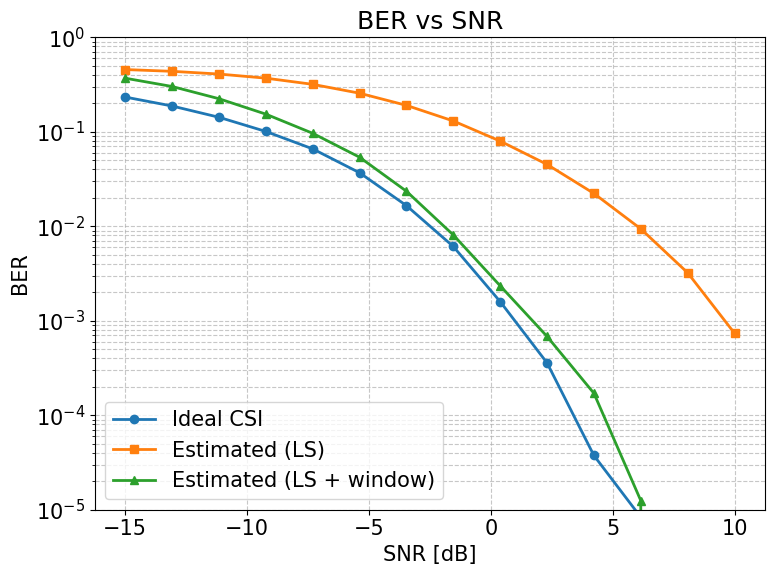

In [36]:
# ----------------------------
# ONE FINAL PLOT (BER vs SNR)
# ----------------------------
plt.figure(figsize=(8,6))
plt.semilogy(snr_range, ber_ideal_precoding, 'o-', lw=2, label='Ideal CSI')
plt.semilogy(snr_range, ber_est_precoding,   's-', lw=2, label='Estimated (LS)')
plt.semilogy(snr_range, ber_windowed_precoding,'^-', lw=2, label='Estimated (LS + window)')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.xlabel('SNR [dB]')
plt.ylabel('BER')
plt.title('BER vs SNR')
plt.ylim(1e-5, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import ifft

def _window_segments_from_w(w):
    """
    Return contiguous index segments where w==1.
    Works for wrap-around windows because w is already a 0/1 mask.
    """
    one_idx = np.where(w > 0.5)[0] #find indices where w is 1 (uses >0.5 to handle float rounding)
    if len(one_idx) == 0:
        return []
    
    breaks = np.where(np.diff(one_idx) != 1)[0] + 1 #difference between  consecutive indices in one_idx, if it's not 1, it means we have a break between segments. +1 to get the index of the next segment start
    return np.split(one_idx, breaks)  #split into contiguous segments of indices where w is 1

def plot_pdp_vs_window(H_LS, w, title=None, y_db_min=-60, y_db_max=0):
    """
    H_LS: (K, N, M)  LS channel estimate in freq
    w:    (K,)       0/1 delay-domain mask
    """
    eps = 1e-12 #small epsilon to avoid log of zero
    K, N, M = H_LS.shape

    # PDP per TX-port (average power over BS antennas)
    # CIR: ifft over subcarriers axis=0 => (K,N,M)
    Z = ifft(H_LS, axis=0, norm="ortho") #convert frequency-domain channel estimate to delay domain (CIR)

    #Average over BS antennas (axis=1) → per-UE-antenna PDP
    #(K, M=4) one PDP curve per Tx antenna
    pdp_ports = np.mean(np.abs(Z)**2, axis=1)               # (K,M)
    pdp_ports = pdp_ports / (np.max(pdp_ports, axis=0, keepdims=True) + eps)  #Normalize each Tx antenna's PDP so max = 1 (0 dB)

    fig, axes = plt.subplots(nrows=M, ncols=1, sharex=True, sharey=True,  #Create M=4 subplots (one per Tx antenna)
                             figsize=(11.5, 8.5))
    if M == 1:
        axes = [axes]

    segs = _window_segments_from_w(w)


    for m_idx, ax in enumerate(axes):
        #pdp_ports[:, m_idx] take the PDP curve for this Tx antenna (shape 600,)
        #pdp_db = array of 600 dB values for the original (unfiltered) PDP of this Tx antenna
        pdp_db = 10*np.log10(pdp_ports[:, m_idx] + eps)

        #Multiples with window, 600 dB values showing PDP after applying your window
        pdp_filt_db = 10*np.log10(pdp_ports[:, m_idx]*w + eps)

        ax.plot(pdp_db, lw=2.0, label=f'PDP for {m_idx+1} Tx-antenna')
        ax.plot(pdp_filt_db, color='r', lw=2.0, label='PDP after filter')

        # Shade filter areas (pink), exactly like your reference
        for s_idx, seg in enumerate(segs): #seg is a contiguous segment of indices where w is 1
            x0, x1 = int(seg[0]), int(seg[-1] + 1)
            lbl = 'Filter area' if (m_idx == 0 and s_idx == 0) else None # label only the first shaded area for the legend
            ax.fill_betweenx([y_db_min, y_db_max], x0, x1, color='r', alpha=0.18, label=lbl) #

        ax.grid(True, alpha=0.7)
        ax.legend(fontsize=11, loc='upper center')
        ax.set_ylim(y_db_min, y_db_max)
        ax.margins(0.002, 0.05)

    axes[-1].set_xticks(np.arange(0, K+1, 25))
    axes[-1].tick_params(axis='x', labelsize=11, rotation=90)

    fig.text(0.5, 0.04, 'Delay bin', ha='center', fontsize=13)
    fig.text(0.06, 0.5, 'Normalized power', va='center', rotation='vertical', fontsize=13)
    if title is not None:
        fig.suptitle(title, fontsize=15, y=0.98)

    plt.tight_layout(rect=[0.03, 0.06, 0.98, 0.95])
    plt.show()

In [38]:
snr_db = 10

Y_pilots = receiver_signal(H_ul_t, S[..., None], SNR_dB=snr_db)
H_LS = estimate_H_LS_from_Y_freq(Y_pilots, S)

# Use get_pdp instead of mean_CIR_from_H_LS
cir_pwr = get_pdp(H_LS, normalize=True, avg_dims=(1,2))

length, position, w = adaptive_window_from_cir_power(cir_pwr, snr_db, shift_step)

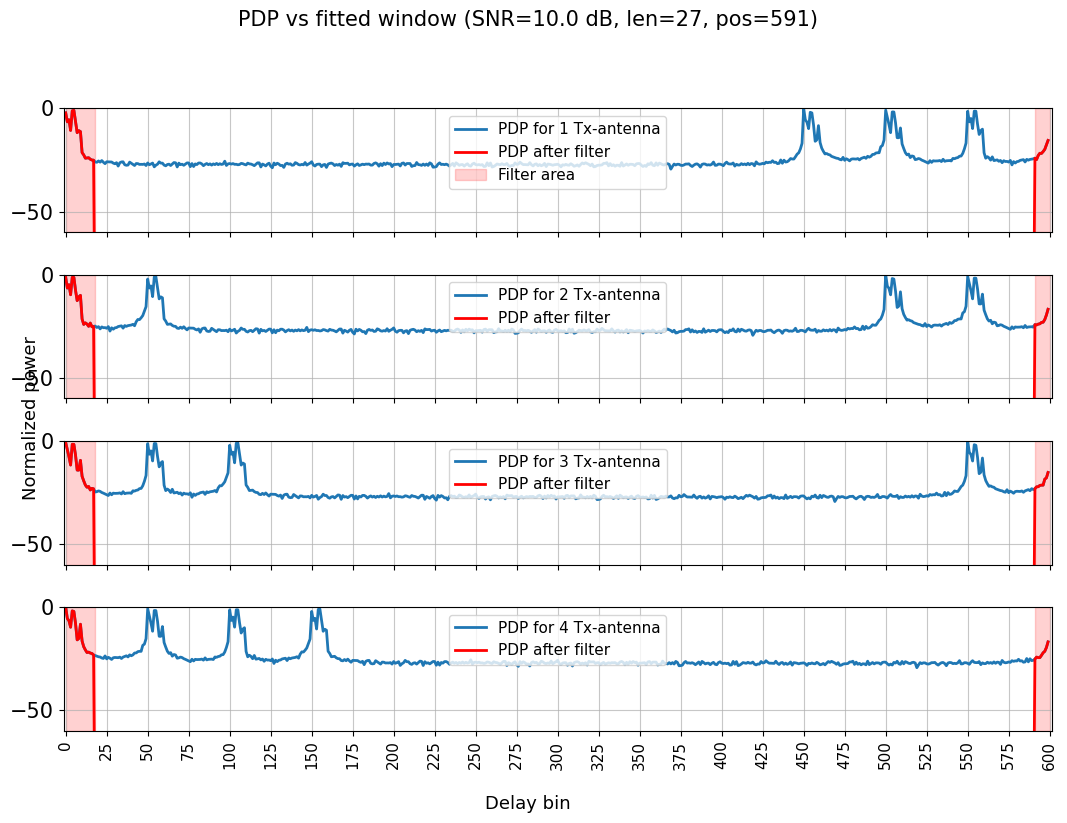

In [39]:
plot_pdp_vs_window(
    H_LS, w,
    title=f"PDP vs fitted window (SNR={snr_db:.1f} dB, len={length}, pos={position})"
)

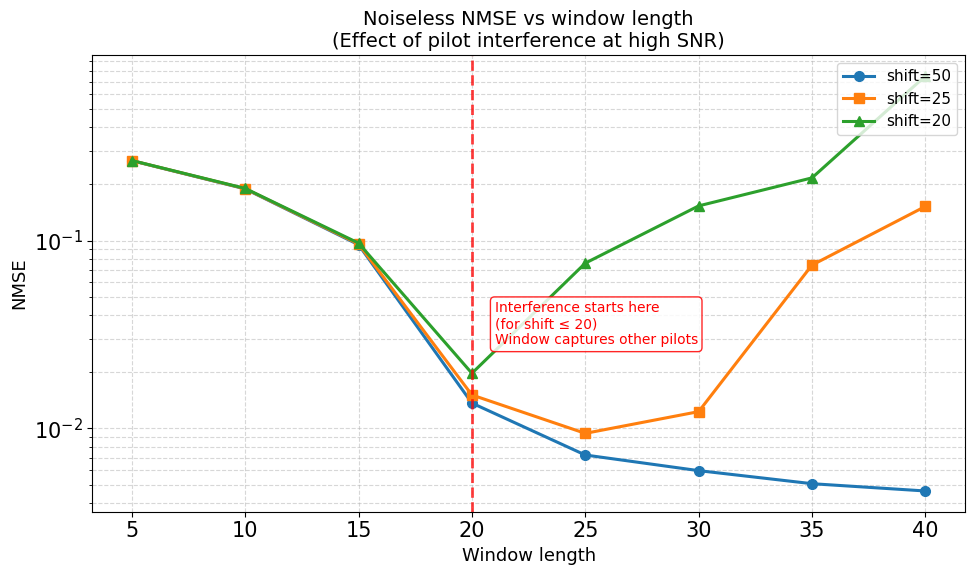

In [41]:
shift_list = [50, 25, 20]
win_lengths = [5, 10, 15, 20, 25, 30, 35, 40]

nmse_results = {}
t0 = 0
H_ul_t = H_UL[t0]

for test_shift in shift_list:
    S_test = toy_srs_zc(K=K, M=M, shift_step=test_shift, root=11)
    Y_pilots = receiver_signal(H_ul_t, S_test[..., None], SNR_dB=None)   # noiseless
    H_LS_test = estimate_H_LS_from_Y_freq(Y_pilots, S_test)

    cir_pwr = get_pdp(H_LS_test, normalize=True, avg_dims=(1,2))
    nmse_vals = []

    for L in win_lengths:
        position, w = fixed_window_around_peak(cir_pwr, L)
        H_win = apply_delay_window_to_H_LS(H_LS_test, w)
        nmse_vals.append(nmse(H_win, H_ul_t))

    nmse_results[test_shift] = np.array(nmse_vals)


plt.figure(figsize=(10, 6))

colors = ['tab:blue', 'tab:orange', 'tab:green']
markers = ['o', 's', '^']

for i, test_shift in enumerate(shift_list):
    plt.semilogy(win_lengths, nmse_results[test_shift], 
                 color=colors[i], marker=markers[i], 
                 lw=2.2, ms=7,          # thinner lines + smaller markers
                 label=f'shift={test_shift}')

#AUTOMATIC INTERFERENCE LINE 
smallest_shift = min(shift_list)
min_idx = np.argmin(nmse_results[smallest_shift])
interference_start = win_lengths[min_idx]

plt.axvline(x=interference_start, color='red', linestyle='--', lw=2.0, alpha=0.75) 
plt.text(interference_start + 1, 0.028, 
         f'Interference starts here\n'
         f'(for shift ≤ {smallest_shift})\n'
         f'Window captures other pilots',
         fontsize=10, color='red', fontweight='normal',   # ← normal weight, smaller font
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor='red'))

plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xlabel('Window length', fontsize=13)
plt.ylabel('NMSE', fontsize=13)
plt.title('Noiseless NMSE vs window length\n(Effect of pilot interference at high SNR)', fontsize=14)
plt.legend(fontsize=11, loc='upper right')
plt.xticks(win_lengths)
plt.tight_layout()
plt.show()

### 🔴 Tasks
1. Implement the channel estimation procedure described above. The filtering window must have a parameter `length` and `position`.

2. Consider a fixed cyclic shift of the Zadoff-Chu sequence (`shift = 50`, as in the provided example). Using received pilot signals $\mathbf{Y}$ corrupted by additive white Gaussian noise, estimate the channel $\hat{\mathcal{H}}$. Analyze the corresponding power delay profile (PDP). Discuss how does noise affect the delay-domain representation?

3. Propose a systematic strategy for selecting the delay-domain window parameters: length and position. Your strategy should account for the known SNR level and channel delay spread. 
4. Using the estimated channel $\hat{\mathcal{H}}$, construct a rank-1 SVD-based precoder and simulate downlink data transmission. Plot and compare BER vs SNR curves for precoding based on ideal channel knowledge (previous homework) and for precoding based on estimated channel knowledge. Analyse and explain the observed perfomance gap.     

### ❓Control questions
1. What properties of Zadoff-Chu sequencies make them suitable for channel estimation? 
2. What are four common methods of orthogonal multiplexing using Zadoff-Chu sequencies?
3. How does the cyclic shift parameter affect the delay-domain separation between pilot signals?
4. Why does delay-domain filtering improve channel estimation accuracy?
5. What is the physical meaning of power-delay profile? 
6. Define delay spread. How can it be estimated from the PDP?
7. How does delay spread affect communication system perfomace?
8. Why should pilot overhead be minimized in practical communication systems?
9. If pilot symbols are transmitted only on a subset of subcarriers, what additional processing is required to estimate the full channel?
10. Can multiple users estimate their channels simultaneously using the same time–frequency resources? Under what conditions?
11. How does channel estimation errors affect precoder perfomance? 
12. What would happen if the filtering window is chosen too small or too large?
13. Can precoding be applied during pilot transmission? How would it affect channel estimation accuracy and system design?